# **Name:** Sayed Meer Ali Shah

# **Objective:** Train LSTM and RNN to predict future crypto BTC abd ETH price

# Fetching Data
we are fetching data from 2021 till 2026, in previous ML approach forecasting we have used 2 years of data and now as we are training deeplearning models which are working better with more data, and for this we fetched 4 years data.


btc_df = fetch_klines(

        Symbol: Which Coin
        interval: interval of trade 1h,2h,1d,1M etc,
        start_date="2021-01-01",
        end_date="2025-12-31"
    )

save fetched data for later use.

save_raw_data(

    df,
    fikename
)

In [1]:
from fetch_data import fetch_klines, save_raw_data

In [2]:

btc_df = fetch_klines(
        "BTCUSDT",
        interval="1d",
        start_date="2021-01-01",
        end_date="2025-12-31"
    )
btc_df.head(2)

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,num_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore
0,2021-01-01,28948.19,29668.86,28627.12,29337.16,210716.398,2021-01-01 23:59:59.999,6157505024.08511,1511793,101247.902,2960175587.62208,0
1,2021-01-02,29337.15,33480.00,28958.24,32199.91,545541.080,2021-01-02 23:59:59.999,17122938614.70610,3514545,273388.463,8578964529.70894,0


In [3]:
eth_df = fetch_klines(
        "ETHUSDT",
        interval="1d",
        start_date="2021-01-01",
        end_date="2025-12-31"
    )
eth_df.head(2)

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,num_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore
0,2021-01-01,737.18,750.40,714.55,729.77,1952291.250,2021-01-01 23:59:59.999,1435726001.91560,1022268,917268.532,674735299.19568,0
1,2021-01-02,729.70,788.71,715.60,775.02,4176508.581,2021-01-02 23:59:59.999,3166570113.30716,1675287,2045884.505,1551475925.67028,0


In [4]:
btc_df.shape,  eth_df.shape

((1860, 12), (1860, 12))

### Save Data for later use

In [5]:
save_raw_data(btc_df,"btc_4y_data.csv")
save_raw_data(eth_df,"eth_4y_data.csv")

Saved data to data/raw\btc_4y_data.csv
Saved data to data/raw\eth_4y_data.csv


# Data Preprocessing & Preparation
- Preprcessing Data
- drop unnecessay columns
- sort data
- feature engineering
- scaling 
- prepare data for training using pytorch

In [6]:
from preprocessing import wrangling, prepare_data

C:\Users\MEER\anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


## 1. Calling wrangling function for preprocessing data

In [7]:
btc_df = wrangling(btc_df) 
eth_df = wrangling(eth_df) 

In [8]:
btc_df.shape, eth_df.shape

((1859, 6), (1859, 6))

In [9]:
btc_df.head(2)

,open,high,low,close,volume,target
0,28948.19,29668.86,28627.12,29337.16,210716.398,32199.91
1,29337.15,33480.00,28958.24,32199.91,545541.080,33054.53


## 2. Calling prepare_data function for data preparation (splitting, scalling, to_Tensor)

### prepare_data(

    df,
    feature_cols = ["open", "high", "low", "close","volume"] ---->,  independent features
    window_size=30 -------> Use the last 30 candles (each with open, high, low, close, volume) to predict the next candle.
    train_ratio=0.8)

In [12]:
(
    X_train_tensor_btc,
    y_train_tensor_btc,
    X_val_tensor_btc,
    y_val_tensor_btc,
    scaler_X_btc,
    scaler_y_btc
) = prepare_data(btc_df)

(
    X_train_tensor_eth,
    y_train_tensor_eth,
    X_val_tensor_eth,
    y_val_tensor_eth,
    scaler_X_eth,
    scaler_y_eth
) = prepare_data(eth_df)


In [13]:
X_train_tensor_btc.shape, y_train_tensor_btc.shape

(torch.Size([1457, 30, 5]), torch.Size([1457, 1]))

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import r2_score


# Creating Dataloader of BTC and ETH

In [15]:
train_loader_btc = DataLoader(
    TensorDataset(X_train_tensor_btc, y_train_tensor_btc),
    batch_size=32,
    shuffle=False
)

val_loader_btc = DataLoader(
    TensorDataset(X_val_tensor_btc, y_val_tensor_btc),
    batch_size=32,
    shuffle=False
)


train_loader_eth = DataLoader(
    TensorDataset(X_train_tensor_eth, y_train_tensor_eth),
    batch_size=32,
    shuffle=False
)

val_loader_eth = DataLoader(
    TensorDataset(X_val_tensor_eth, y_val_tensor_eth),
    batch_size=32,
    shuffle=False
)

## Train RNN Model on BTC

In [20]:
from train_models import SimpleRNN, train_rnn, get_predictions_rnn

In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"

rnn_btc_model = SimpleRNN(input_size=5, hidden_size=64).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(rnn_btc_model.parameters(), lr=0.001)


In [22]:
train_rnn(num_epochs=20, model = rnn_btc_model, train_loader=train_loader_btc, device=device, optimizer=optimizer, criterion=criterion)

RNN Epoch [1/20], Loss: 0.4008
RNN Epoch [2/20], Loss: 0.2148
RNN Epoch [3/20], Loss: 0.1319
RNN Epoch [4/20], Loss: 0.0739
RNN Epoch [5/20], Loss: 0.0602
RNN Epoch [6/20], Loss: 0.0584
RNN Epoch [7/20], Loss: 0.0626
RNN Epoch [8/20], Loss: 0.0615
RNN Epoch [9/20], Loss: 0.0548
RNN Epoch [10/20], Loss: 0.0742
RNN Epoch [11/20], Loss: 0.0649
RNN Epoch [12/20], Loss: 0.0867
RNN Epoch [13/20], Loss: 0.0554
RNN Epoch [14/20], Loss: 0.0602
RNN Epoch [15/20], Loss: 0.0582
RNN Epoch [16/20], Loss: 0.0541
RNN Epoch [17/20], Loss: 0.0559
RNN Epoch [18/20], Loss: 0.0456
RNN Epoch [19/20], Loss: 0.0484
RNN Epoch [20/20], Loss: 0.0575


In [23]:
y_train_true, y_train_pred = get_predictions_rnn(
    rnn_btc_model, train_loader_btc, scaler_y_btc, device
)

train_r2 = r2_score(y_train_true, y_train_pred)
print("RNN BTC TRAIN R²:", train_r2)

y_val_true, y_val_pred = get_predictions_rnn(
    rnn_btc_model, val_loader_btc, scaler_y_btc, device
)

val_r2 = r2_score(y_val_true, y_val_pred)
print("RNN BTC VAL R²:", val_r2)

RNN BTC TRAIN R²: 0.9844762560322922
RNN BTC VAL R²: 0.9264839807151116


In [24]:
torch.save(rnn_btc_model.state_dict(), "models/rnn_btc.pt")
torch.save(scaler_X_btc, "models/scaler_X_btc.pkl")
torch.save(scaler_y_btc, "models/scaler_y_btc.pkl")

# Training RNN ON ETH

In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"

rnn_eth_model = SimpleRNN(input_size=5, hidden_size=64).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(rnn_eth_model.parameters(), lr=0.001)


In [27]:
train_rnn(num_epochs=20, model = rnn_eth_model, train_loader=train_loader_eth, device=device, optimizer=optimizer, criterion=criterion)

RNN Epoch [1/20], Loss: 0.6545
RNN Epoch [2/20], Loss: 0.2374
RNN Epoch [3/20], Loss: 0.1358
RNN Epoch [4/20], Loss: 0.1118
RNN Epoch [5/20], Loss: 0.0897
RNN Epoch [6/20], Loss: 0.1140
RNN Epoch [7/20], Loss: 0.1322
RNN Epoch [8/20], Loss: 0.1302
RNN Epoch [9/20], Loss: 0.1088
RNN Epoch [10/20], Loss: 0.0952
RNN Epoch [11/20], Loss: 0.0821
RNN Epoch [12/20], Loss: 0.0796
RNN Epoch [13/20], Loss: 0.0678
RNN Epoch [14/20], Loss: 0.0638
RNN Epoch [15/20], Loss: 0.0669
RNN Epoch [16/20], Loss: 0.0699
RNN Epoch [17/20], Loss: 0.0675
RNN Epoch [18/20], Loss: 0.0604
RNN Epoch [19/20], Loss: 0.0640
RNN Epoch [20/20], Loss: 0.0629


In [28]:
y_train_true, y_train_pred = get_predictions_rnn(
    rnn_eth_model, train_loader_eth, scaler_y_eth, device
)

train_r2 = r2_score(y_train_true, y_train_pred)
print("RNN ETH TRAIN R²:", train_r2)

y_val_true, y_val_pred = get_predictions_rnn(
    rnn_eth_model, val_loader_eth, scaler_y_eth, device
)

val_r2 = r2_score(y_val_true, y_val_pred)
print("RNN ETH VAL R²:", val_r2)

RNN ETH TRAIN R²: 0.943546922397082
RNN ETH VAL R²: 0.9379069438292905


In [29]:
torch.save(rnn_eth_model.state_dict(), "models/rnn_eth.pt")
torch.save(scaler_X_eth, "models/scaler_X_eth.pkl")
torch.save(scaler_y_eth, "models/scaler_y_eth.pkl")

# Training LSTM on BTC

In [31]:
from train_models import LSTMModel, train_lstm, get_predictions_lstm

In [32]:
device = "cuda" if torch.cuda.is_available() else "cpu"

lstm_btc_model = LSTMModel(input_size=5, hidden_size=64).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_btc_model.parameters(), lr=0.001, weight_decay=1e-5)


In [33]:
train_lstm(num_epochs = 20, model = lstm_btc_model, 
           train_loader = train_loader_btc, device = device, 
           optimizer = optimizer, criterion = criterion)

LSTM Epoch [1/20], Loss: 0.8893
LSTM Epoch [2/20], Loss: 0.3354
LSTM Epoch [3/20], Loss: 0.2717
LSTM Epoch [4/20], Loss: 0.1584
LSTM Epoch [5/20], Loss: 0.0929
LSTM Epoch [6/20], Loss: 0.0955
LSTM Epoch [7/20], Loss: 0.0917
LSTM Epoch [8/20], Loss: 0.0883
LSTM Epoch [9/20], Loss: 0.0836
LSTM Epoch [10/20], Loss: 0.0673
LSTM Epoch [11/20], Loss: 0.0710
LSTM Epoch [12/20], Loss: 0.0755
LSTM Epoch [13/20], Loss: 0.0710
LSTM Epoch [14/20], Loss: 0.0668
LSTM Epoch [15/20], Loss: 0.0709
LSTM Epoch [16/20], Loss: 0.0706
LSTM Epoch [17/20], Loss: 0.0783
LSTM Epoch [18/20], Loss: 0.0779
LSTM Epoch [19/20], Loss: 0.0780
LSTM Epoch [20/20], Loss: 0.0760


In [34]:
y_train_true, y_train_pred = get_predictions_lstm(
    lstm_btc_model, train_loader_btc, scaler_y_btc, device
)

train_r2 = r2_score(y_train_true, y_train_pred)
print("LSTM BTC TRAIN R²:", train_r2)


y_val_true, y_val_pred = get_predictions_lstm(
    lstm_btc_model, val_loader_btc, scaler_y_btc, device
)

val_r2 = r2_score(y_val_true, y_val_pred)
print("LSTM BTC VAL R²:", val_r2)


LSTM BTC TRAIN R²: 0.9734068308991115
LSTM BTC VAL R²: 0.8168923899651017


In [35]:
torch.save(lstm_btc_model.state_dict(), "models/lstm_btc_model.pt")

# Training LSTM on ETH

In [36]:
device = "cuda" if torch.cuda.is_available() else "cpu"

lstm_eth_model = LSTMModel(input_size=5, hidden_size=64).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_eth_model.parameters(), lr=0.001, weight_decay=1e-5)


In [37]:
train_lstm(num_epochs = 20, model = lstm_eth_model, 
           train_loader = train_loader_eth, device = device, 
           optimizer = optimizer, criterion = criterion)

LSTM Epoch [1/20], Loss: 0.8404
LSTM Epoch [2/20], Loss: 0.3267
LSTM Epoch [3/20], Loss: 0.1491
LSTM Epoch [4/20], Loss: 0.1201
LSTM Epoch [5/20], Loss: 0.1150
LSTM Epoch [6/20], Loss: 0.1691
LSTM Epoch [7/20], Loss: 0.1579
LSTM Epoch [8/20], Loss: 0.0979
LSTM Epoch [9/20], Loss: 0.0860
LSTM Epoch [10/20], Loss: 0.0920
LSTM Epoch [11/20], Loss: 0.0939
LSTM Epoch [12/20], Loss: 0.0817
LSTM Epoch [13/20], Loss: 0.0760
LSTM Epoch [14/20], Loss: 0.0760
LSTM Epoch [15/20], Loss: 0.0825
LSTM Epoch [16/20], Loss: 0.0749
LSTM Epoch [17/20], Loss: 0.0786
LSTM Epoch [18/20], Loss: 0.0928
LSTM Epoch [19/20], Loss: 0.1150
LSTM Epoch [20/20], Loss: 0.1224


In [38]:
y_train_true, y_train_pred = get_predictions_lstm(
    lstm_eth_model, train_loader_eth, scaler_y_eth, device
)

train_r2 = r2_score(y_train_true, y_train_pred)
print("LSTM ETH TRAIN R²:", train_r2)


y_val_true, y_val_pred = get_predictions_lstm(
    lstm_eth_model, val_loader_eth, scaler_y_eth, device
)

val_r2 = r2_score(y_val_true, y_val_pred)
print("LSTM ETH VAL R²:", val_r2)


LSTM ETH TRAIN R²: 0.9427647905743866
LSTM ETH VAL R²: 0.9129291354856366


In [39]:
torch.save(lstm_eth_model.state_dict(), "models/lstm_eth_model.pt")

# Inferencing on new data coming from Binance API

In [41]:
from fetch_data import fetch_klines, save_raw_data
import pandas as pd
btc_df = fetch_klines(
        "BTCUSDT",
        interval="1d",
        start_date="2026-01-01",
        end_date=pd.Timestamp.today().strftime("%Y-%m-%d")
    )
btc_df.head(2)

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,num_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore
0,2026-01-01,87608.3,88881.4,87508.4,88800.0,47941.303,2026-01-01 23:59:59.999,4221684071.52160,1056983,24309.438,2140634699.04340,0
1,2026-01-02,88800.0,90945.1,88324.4,89951.4,176662.448,2026-01-02 23:59:59.999,15818436364.51320,3761821,88056.870,7886732816.13240,0


In [42]:
btc_df.shape

(34, 12)

In [1]:
from inference import run_inference
from train_models import SimpleRNN, LSTMModel

C:\Users\MEER\anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


C:\Users\MEER\Downloads\AI Internship JMM\Module 4 DL\DL crypto Forecasting\inference.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(m

Predicted next-day close price for BTCUSDT: 78904.91


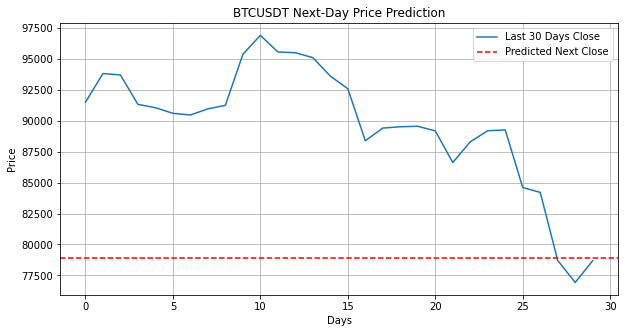

C:\Users\MEER\Downloads\AI Internship JMM\Module 4 DL\DL crypto Forecasting\inference.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(m

Predicted next-day close price for ETHUSDT: 2337.98


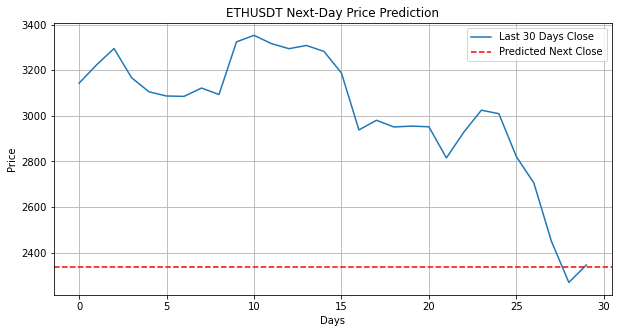

2337.9802

In [6]:
# RNN BTC Prediction
run_inference(
    symbol="BTCUSDT",
    model_path="models/rnn_btc.pt",        # correct
    scaler_X_path="models/scaler_X_btc.pkl",
    scaler_y_path="models/scaler_y_btc.pkl",
    model_class=SimpleRNN,
    start_date="2026-01-01",
    interval="1d"
)

# LSTM ETH Prediction
run_inference(
    symbol="ETHUSDT",
    model_path="models/lstm_eth_model.pt",       # correct extension
    scaler_X_path="models/scaler_X_eth.pkl",
    scaler_y_path="models/scaler_y_eth.pkl",
    model_class=LSTMModel,
    start_date="2026-01-01",
    interval="1d"
)


# 📊 Model Performance Interpretation: BTC vs ETH (RNN & LSTM)

## 🔹 Experimental Setup
- **Data**: 4 years of daily OHLCV crypto data
- **Window size**: 30 days
- **Target**: Next-day price (t+1)
- **Models**: Vanilla RNN, LSTM
- **Coins**: BTC (high volatility), ETH (relatively lower volatility)
- **Metric**: R² score

---

## 🔹 Results Summary

| Model | Coin | Train R² | Validation R² | Observation |
|-----|------|----------|---------------|-------------|
| RNN | BTC | 0.9844 | 0.9264 | ✅ Strong generalization |
| RNN | ETH | 0.9435 | 0.9379 | ✅ Very stable |
| LSTM | BTC |0.9734 | 0.8168 | ❌ Severe overfitting |
| LSTM | ETH | 0.9427 | 0.9129 | ✅ Good generalization |

---

## 🔹 Key Observations

1. **ETH behaves well across both RNN and LSTM**
   - Low train–validation gap
   - Indicates smoother temporal dynamics
   - Lower volatility → more predictable short-term structure

2. **BTC shows model-dependent behavior**
   - RNN generalizes well
   - LSTM severely overfits (high train R², poor validation R²)

---

## 🔹 Core Question
**Why does a simpler RNN perform better on BTC, while a more powerful LSTM overfits badly?**

---

## 🧠 Deep Technical Explanation

### 1️⃣ Volatility vs Memory Length Mismatch

- **BTC** is highly volatile and regime-changing
- With `window_size = 30`, the task is **short-term prediction**
- **LSTM is designed for long-term dependency retention**
- In BTC:
  - Long-term memory often becomes **noise**
  - Market structure changes invalidate older signals

📌 LSTM *memorizes what should be forgotten* in BTC

RNN, on the other hand:
- Has **shorter effective memory**
- Naturally forgets faster
- Aligns better with BTC’s short-term chaotic dynamics

---

### 2️⃣ Parameter Count & Capacity Overkill

| Model | Relative Complexity |
|-----|---------------------|
| RNN | Low |
| LSTM | ~4× parameters (gates, cell state) |

- Your dataset size (~1456 windows) is **small for LSTM**
- BTC’s noisy signal + high-capacity LSTM =
  > **Learning noise instead of structure**

ETH:
- Smoother patterns
- Lower entropy
- LSTM capacity is actually *used meaningfully*

BTC:
- LSTM capacity is *wasted memorizing volatility spikes*

---

### 3️⃣ Gating Mechanism Failure in BTC

LSTM relies on:
- **Forget gate**
- **Input gate**
- **Output gate**

These gates assume:
> “Some past information remains relevant for a long time”

This assumption:
- ✔️ Holds for ETH
- ❌ Breaks for BTC

BTC price dynamics:
- Dominated by exogenous shocks
- Non-stationary regimes
- Rapid trend reversals

So the LSTM gates:
- Fail to generalize
- Over-specialize to training sequences

---

### 4️⃣ RNN as an Implicit Regularizer

In your experiment:

> **The RNN’s weakness became its strength**

- No cell state
- No long-term memory
- No complex gating

This acts like:
- A **regularization mechanism**
- Forces the model to focus on:
  - recent momentum
  - short-term correlations
  - immediate volatility

Which is *exactly what BTC rewards*.

---

### 5️⃣ Why ETH Works for Both Models

ETH characteristics:
- Lower volatility
- Fewer violent regime changes
- More autocorrelation in short-term trends

Therefore:
- LSTM memory is useful
- Gates learn meaningful patterns
- Overfitting is reduced

---

## 🔹 Final Interpretation (In One Sentence)

> **LSTM overfits BTC because it remembers too much in a market that rewards forgetting, while RNN generalizes better by focusing only on short-term dynamics.**

---

## 🔹 Practical Takeaways

- ✅ Model complexity must match **market entropy**
- ❌ “More powerful model” ≠ “better model”
- 📉 High volatility → prefer **short-memory models**
- 📈 Smooth assets → LSTM / GRU can shine

---

## 🔹 What You Can Try Next

- Increase window size (60–90) for LSTM
- Predict **returns instead of price**
- Try **GRU** (often best middle-ground)

---

## Bottom Line

Your results are **not a failure of LSTM**  
They are a **correct reflection of BTC’s chaotic nature**

You discovered something *real* — and that’s excellent research work 👊



![Crypto Volatility](plot/volatility.png)